In [1]:
# =========================================================
# INSTALAÇÃO DOS PACOTES
# =========================================================

install.packages("tidyverse")
install.packages("naniar")
install.packages("visdat")
install.packages("MissMech")
install.packages("corrplot")
install.packages("mice")
install.packages("psych")
install.packages("skimr")
install.packages("Rdpack")

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'tidyverse' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\Rtmp257pMQ\downloaded_packages


Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'naniar' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\Rtmp257pMQ\downloaded_packages


Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



...

package 'mice' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\Rtmp257pMQ\downloaded_packages


Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'psych' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\Rtmp257pMQ\downloaded_packages


Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'skimr' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\Rtmp257pMQ\downloaded_packages


In [4]:
# =========================================================
# CARREGAR PACOTES
# =========================================================

library(tidyverse)

# glimpse()
library(dplyr)
library(tidyr)
library(ggplot2)
library(readr)

# visualização de missing
library(naniar)
library(visdat)

# teste MCAR de Little
library(MissMech)

# correlogramas
library(corrplot)

# imputação múltipla
library(mice)

# análises psicométricas futuras
library(psych)

# relatórios descritivos
library(skimr)

corrplot 0.95 loaded


Anexando pacote: 'mice'


O seguinte objeto é mascarado por 'package:stats':

    filter


Os seguintes objetos são mascarados por 'package:base':

    cbind, rbind



Anexando pacote: 'psych'


Os seguintes objetos são mascarados por 'package:ggplot2':

    %+%, alpha



Anexando pacote: 'skimr'


O seguinte objeto é mascarado por 'package:naniar':

    n_complete




### ETAPA 1 — BASE DE DADOS

In [17]:
# =========================================================
# IMPORTAR BASE
# =========================================================

onet <- read.csv(
  "onet-v6.txt",
  check.names = FALSE
)

### ETAPA 2 — CRIAR IDENTIFICADOR ÚNICO

In [18]:
onet <- onet %>%
  mutate(
    `Element and Scale` =
      paste(
        `Element Name`,
        `Scale Name`,
        sep = " - "
      )
  )

### ETAPA 3 — Z-SCORE POR SCALE ID

In [19]:
onet <- onet %>%
  group_by(`Scale ID`) %>%
  mutate(
    z_Data_Value =
      as.numeric(
        scale(`Data Value`)
      )
  ) %>%
  ungroup()

In [20]:
summary(onet$z_Data_Value)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-1.86211 -0.72075  0.08133  0.00000  0.69091  3.25147 

### ETAPA 3.5 — COBERTURA LONGITUDINAL

Version Year,ocupacoes,elementos
<int>,<int>,<int>
2017,683,320
2019,612,320
2021,715,320
2023,715,320
2025,725,320


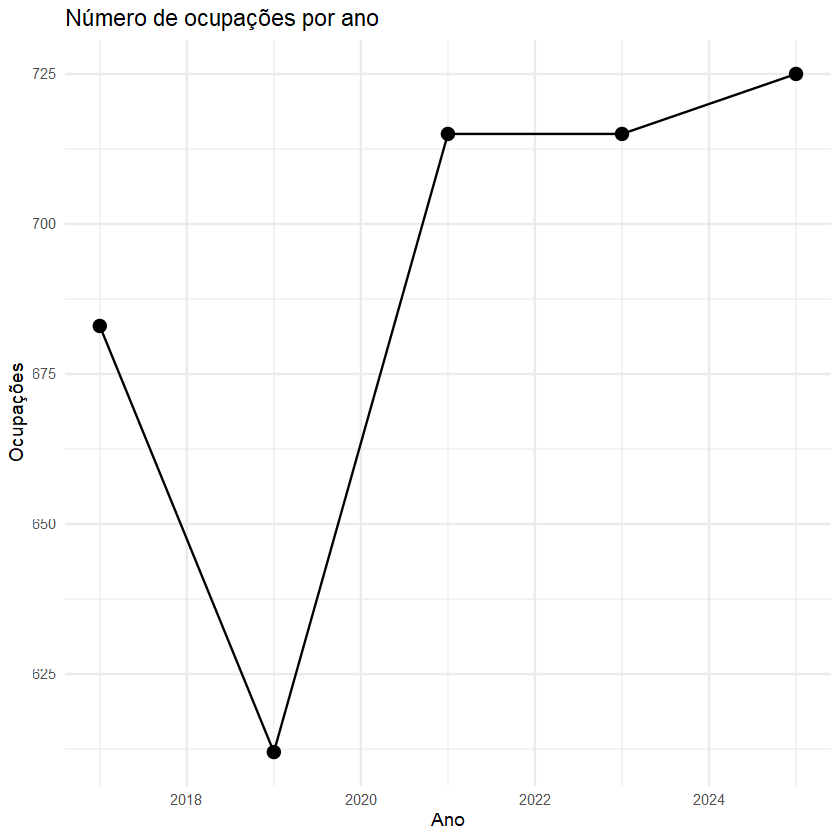

In [21]:
# =========================================================
# COBERTURA LONGITUDINAL
# =========================================================

coverage_year <- onet %>%
  group_by(`Version Year`) %>%
  summarise(
    ocupacoes = n_distinct(`O*NET-SOC Code`),
    elementos = n_distinct(`Element and Scale`)
  )

coverage_year

ggplot(
  coverage_year,
  aes(
    x = `Version Year`,
    y = ocupacoes
  )
) +
  geom_line() +
  geom_point(size = 3) +
  theme_minimal() +
  labs(
    title = "Número de ocupações por ano",
    x = "Ano",
    y = "Ocupações"
  )

### ETAPA 4 — CONSTRUIR PAINEL LONGITUDINAL

In [22]:
anos_disponiveis <-
  sort(
    unique(
      onet$`Version Year`
    )
  )

anos_disponiveis

[1] 2017 2019 2021 2023 2025

In [23]:
occ_long <- onet %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_years =
      n_distinct(`Version Year`)
  ) %>%
  filter(
    n_years ==
      length(anos_disponiveis)
  )

In [24]:
sample_long <- onet %>%
  filter(
    `O*NET-SOC Code`
    %in%
    occ_long$`O*NET-SOC Code`
  )

In [25]:
retention_report <- tibble(

  indicador = c(
    "Ocupações originais",
    "Ocupações longitudinais"
  ),

  valor = c(
    n_distinct(
      onet$`O*NET-SOC Code`
    ),
    n_distinct(
      sample_long$`O*NET-SOC Code`
    )
  )
)

retention_report

indicador,valor
<chr>,<int>
Ocupações originais,798
Ocupações longitudinais,610


In [26]:
100 *
n_distinct(
  sample_long$`O*NET-SOC Code`
) /
n_distinct(
  onet$`O*NET-SOC Code`
)

[1] 76.4411

In [27]:
balance_check <- sample_long %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    anos =
      n_distinct(
        `Version Year`
      ),
    .groups = "drop"
  )

summary(balance_check$anos)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      5       5       5       5       5       5 

### ETAPA 5 — TRANSFORMAR PARA WIDE

In [28]:
panel_wide <- sample_long %>%
  select(
    `O*NET-SOC Code`,
    Title,
    `Version Year`,
    `Element and Scale`,
    z_Data_Value
  ) %>%
  pivot_wider(
    names_from =
      `Element and Scale`,
    values_from =
      z_Data_Value,
    values_fn =
      mean
  )

In [29]:
dim(panel_wide)

[1] 3050  339

### ETAPA 6 — RELATÓRIO DE MISSING

In [30]:
global_missing <-
  mean(
    is.na(panel_wide)
  ) * 100

global_missing

[1] 6.943276

In [31]:
missing_var <- panel_wide %>%
  summarise(
    across(
      everything(),
      ~ mean(is.na(.))*100
    )
  ) %>%
  pivot_longer(
    everything(),
    names_to =
      "variable",
    values_to =
      "missing_pct"
  ) %>%
  arrange(
    desc(missing_pct)
  )

In [32]:
head(missing_var,20)

variable,missing_pct
<chr>,<dbl>
Clerical - Level,62.16393
Interacting With Computers - Level,62.00000
Communicating with Persons Outside Organization - Level,60.91803
"Inspecting Equipment, Structures, or Material - Level",60.65574
Provide Consultation and Advice to Others - Level,60.52459
Operation Monitoring - Level,60.09836
"Judging the Qualities of Things, Services, or People - Level",60.09836
"Monitor Processes, Materials, or Surroundings - Level",60.06557
Clerical - Importance,60.00000


In [33]:
missing_year <- panel_wide %>%
  group_by(`Version Year`) %>%
  summarise(
    missing_pct =
      mean(
        is.na(across(everything()))
      )*100
  )

In [34]:
missing_year

Version Year,missing_pct
<int>,<dbl>
2017,6.963333
2019,6.911922
2021,6.932777
2023,6.972548
2025,7.038510


### ETAPA 7 — VISUALIZAÇÕES

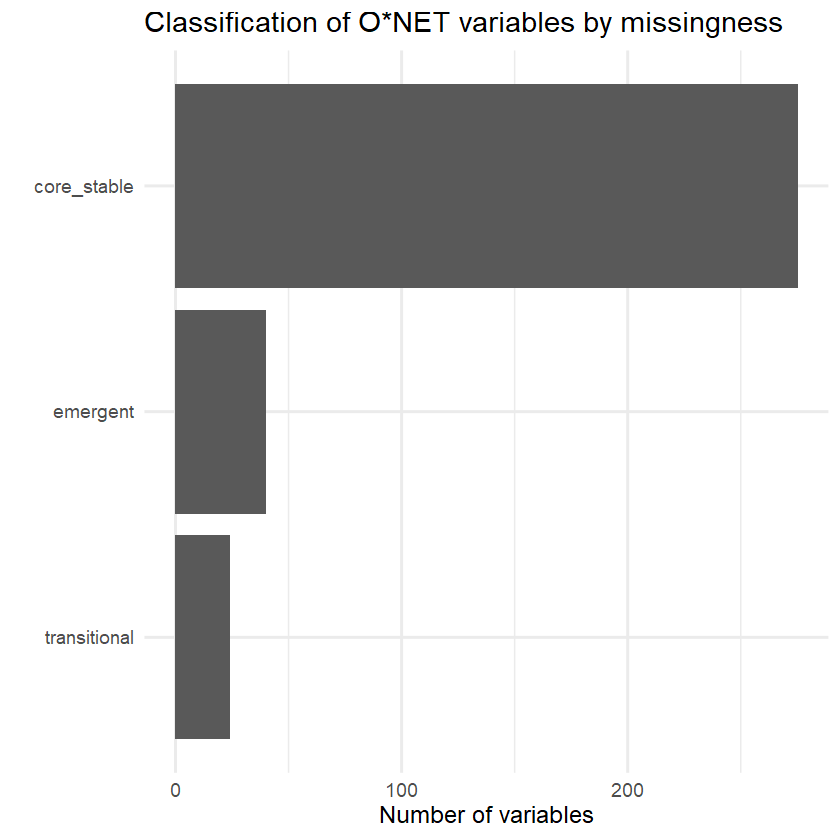

In [66]:
ggplot(
  classification_report,
  aes(
    x = reorder(categoria, n),
    y = n
  )
) +
  geom_col() +
  coord_flip() +
  theme_minimal(base_size = 14) +
  labs(
    title = "Classification of O*NET variables by missingness",
    x = "",
    y = "Number of variables"
  )

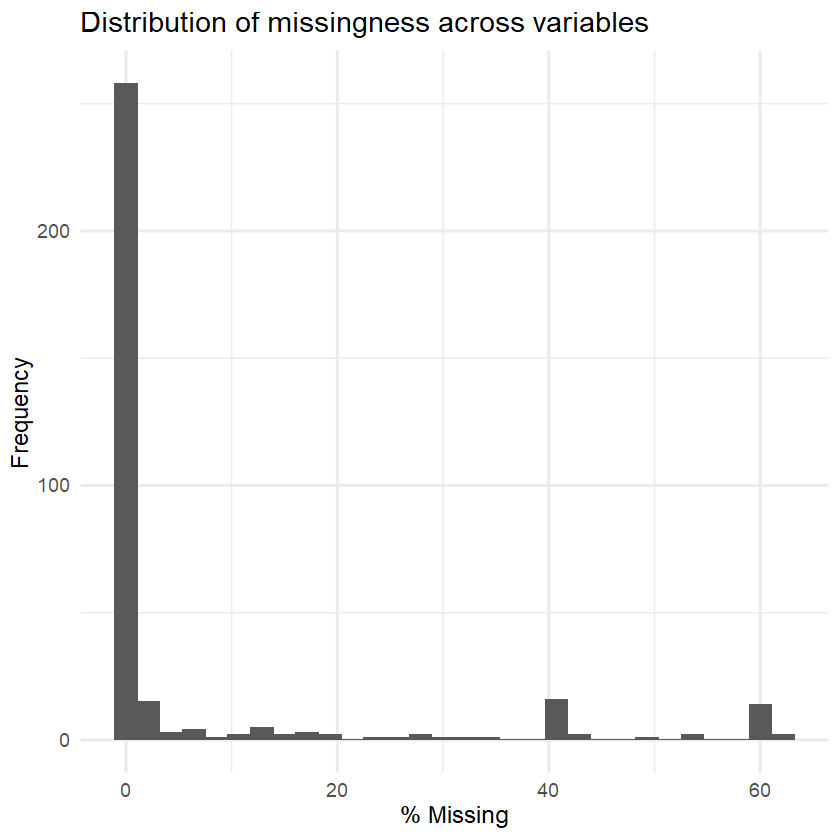

In [67]:
ggplot(
  classified_vars,
  aes(x = missing_pct)
) +
  geom_histogram(
    bins = 30
  ) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Distribution of missingness across variables",
    x = "% Missing",
    y = "Frequency"
  )

In [68]:
top_missing <- classified_vars %>%
  slice_max(
    missing_pct,
    n = 30
  )

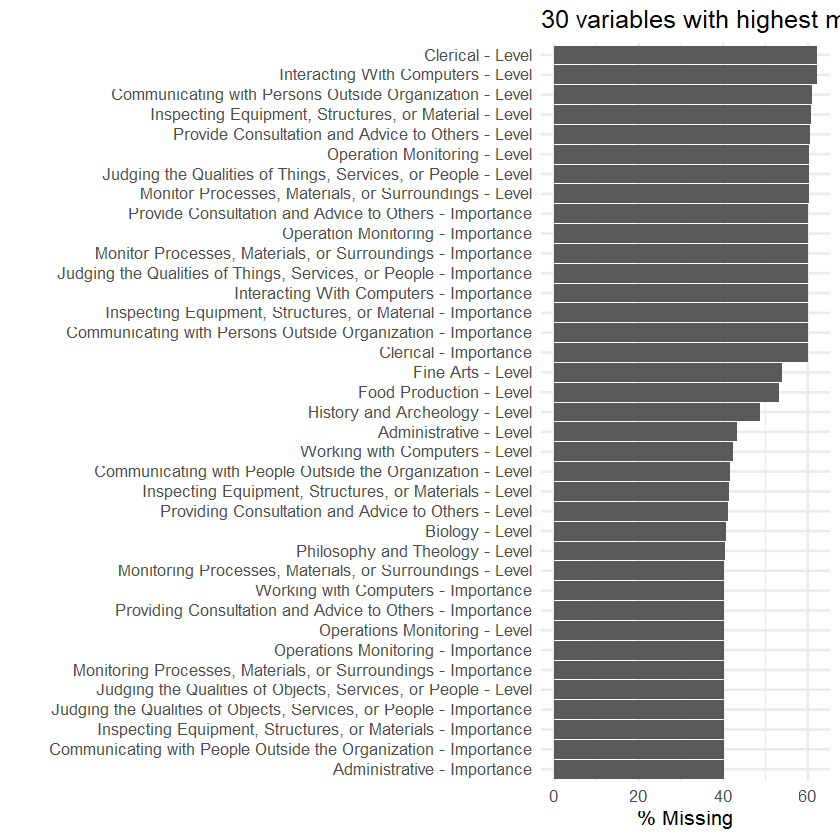

In [69]:
ggplot(
  top_missing,
  aes(
    x = reorder(variable, missing_pct),
    y = missing_pct
  )
) +
  geom_col() +
  coord_flip() +
  theme_minimal(base_size = 12) +
  labs(
    title = "30 variables with highest missingness",
    x = "",
    y = "% Missing"
  )

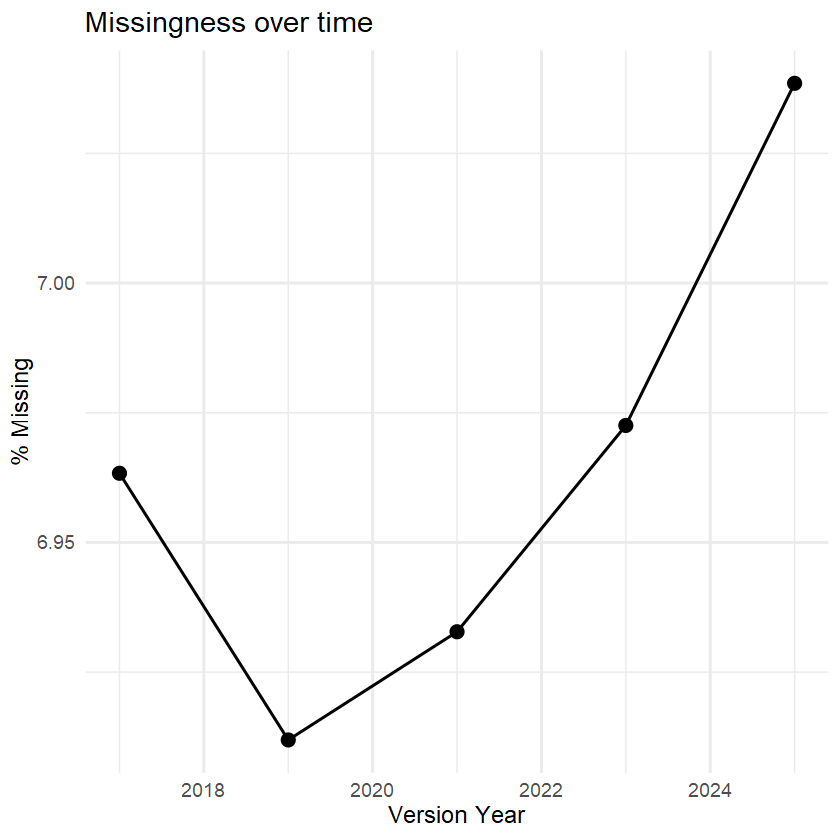

In [71]:
ggplot(
  missing_year,
  aes(
    x = `Version Year`,
    y = missing_pct
  )
) +
  geom_line() +
  geom_point(size = 3) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Missingness over time",
    x = "Version Year",
    y = "% Missing"
  )

In [72]:
quality_report <- tibble(

  Metric = c(
    "Original occupations",
    "Balanced-panel occupations",
    "Retention (%)",
    "Years",
    "Variables",
    "Observations"
  ),

  Value = c(
    798,
    610,
    round(610/798*100,2),
    length(unique(panel_wide$`Version Year`)),
    ncol(panel_wide)-3,
    nrow(panel_wide)
  )
)

quality_report

Metric,Value
<chr>,<dbl>
Original occupations,798.00
Balanced-panel occupations,610.00
Retention (%),76.44
Years,5.00
Variables,336.00
Observations,3050.00


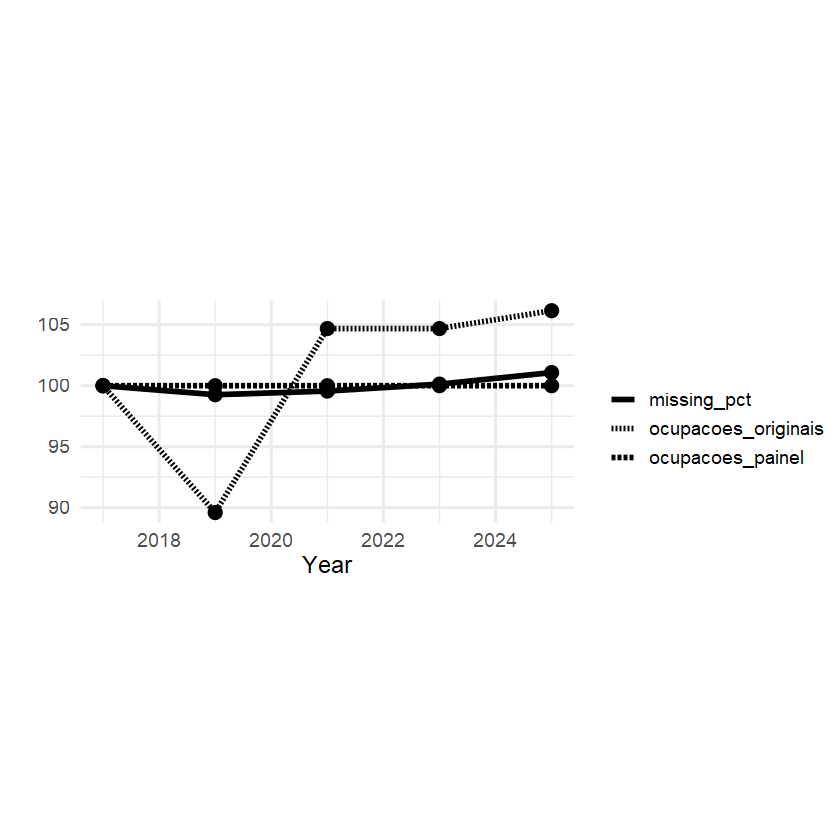

In [78]:
# =========================================================
# GRÁFICO LONGITUDINAL - ÍNDICE BASE 100
# =========================================================

occupations_year <- onet %>%
  group_by(`Version Year`) %>%
  summarise(
    ocupacoes_originais =
      n_distinct(`O*NET-SOC Code`),
    .groups = "drop"
  )

balanced_year <- sample_long %>%
  group_by(`Version Year`) %>%
  summarise(
    ocupacoes_painel =
      n_distinct(`O*NET-SOC Code`),
    .groups = "drop"
  )

plot_data <- occupations_year %>%
  left_join(
    balanced_year,
    by = "Version Year"
  ) %>%
  left_join(
    missing_year,
    by = "Version Year"
  ) %>%
  mutate(

    ocupacoes_originais =
      ocupacoes_originais /
      first(ocupacoes_originais) * 100,

    ocupacoes_painel =
      ocupacoes_painel /
      first(ocupacoes_painel) * 100,

    missing_pct =
      missing_pct /
      first(missing_pct) * 100
  ) %>%
  pivot_longer(
    -`Version Year`,
    names_to = "serie",
    values_to = "indice"
  )

ggplot(
  plot_data,
  aes(
    x = `Version Year`,
    y = indice,
    group = serie,
    linetype = serie
  )
) +
  geom_line(
    linewidth = 1.2
  ) +
  geom_point(
    size = 3
  ) +
  theme_minimal(base_size = 14) +
  theme(
    aspect.ratio = 0.45
  ) +
  labs(
    title = "",
    x = "Year",
    y = "",
    linetype = ""
  )

### ETAPA 8 — CLASSIFICAÇÃO DAS VARIÁVEIS

In [35]:
classified_vars <- missing_var %>%
  mutate(
    categoria =
      case_when(

        missing_pct <= 5 ~
          "core_stable",

        missing_pct <= 30 ~
          "transitional",

        missing_pct <= 70 ~
          "emergent",

        TRUE ~
          "sparse"
      )
  )

In [36]:
classification_report <- classified_vars %>%
  count(categoria) %>%
  mutate(
    percentual =
      round(
        n/sum(n)*100,
        2
      )
  ) %>%
  arrange(desc(n))

classification_report

categoria,n,percentual
<chr>,<int>,<dbl>
core_stable,275,81.12
emergent,40,11.80
transitional,24,7.08


### ETAPA 9 — MATRIZ FINAL

In [37]:
valid_vars <- classified_vars %>%
  filter(
    categoria != "sparse"
  ) %>%
  pull(variable)

### ETAPA 10 — EXPORTAÇÃO

In [54]:
write.table(
  panel_wide,
  "missing.txt",
  sep = "\t",
  quote = FALSE,
  row.names = FALSE,
  fileEncoding = "UTF-8"
)